## This code implements and simulates an LQR controller for a self-balancing bicycle system. The simulated responses are compared with experimental data, and the results are plotted for analysis.

In [12]:
# =========================
# Library imports
# =========================

import numpy as np # Numerical operations and matrix manipulation
import control as ctrl # Control systems library
import matplotlib.pyplot as plt # Plotting and visualization library


# =========================
# Figure formatting setup
# =========================

# Configures default plot appearance
plt.rcParams.update({

    # Uses serif fonts in all figures
    "font.family": "serif",

    # Sets Times New Roman as the main font
    "font.serif": ["Times New Roman"],

    # Uses STIX fonts for mathematical expressions
    "mathtext.fontset": "stix",

    # Ensures editable text in exported PDF files
    "pdf.fonttype": 42
})

### Development of the linear model and LQR controller for the self-balancing bicycle system.

In [13]:
# =========================
# System parameters
# =========================

Mb   = 0.815      # Bicycle body mass (kg)
g    = 9.8        # Gravity acceleration (m/s²)
L_ab = 0.085      # Distance from center of mass to pivot axis (m)
Iw   = 0.000378   # Wheel inertia (kg.m²)
I    = 0.00748    # Body inertia (kg.m²)
k    = 0.0381     # Motor constant
R    = 4.13       # Motor resistance (Ohms)
b    = 0.000133   # Viscous friction coefficient


# =========================
# Auxiliary model constants
# =========================

k1 = (Mb * g * L_ab) / (I + Iw)
k2 = (b * R + k**2) / (R * (I + Iw))
k3 = -(b * R + k**2) / (R * Iw)
k4 = -k / (R * (I + Iw))
k5 =  k / (R * Iw)


# =========================
# State-space model
# =========================
# x = [angle, angular velocity, wheel speed, wheel position]

# State matrix
A = np.zeros((4, 4))
A[0, 1] = 1
A[1, 0] = k1
A[1, 2] = k2
A[2, 2] = k3
A[3, 2] = -1


# Input matrix
B = np.array([[0],
              [k4],
              [k5],
              [0]])

# Output matrix (all states measured)
C = np.eye(4)

# Direct transmission matrix
D = np.zeros((4,1))


# =========================
# LQR weighting matrices
# =========================

# State weighting matrix
Q = np.eye(4)

# Penalizes tilt angle
Q[0, 0] = 33

# Penalizes angular velocity
Q[1, 1] = 0.3

# Penalizes wheel speed
Q[2, 2] = 0.000015

# Penalizes wheel position
Q[3, 3] = 0.000001

# Control effort weighting
R_lqr = np.array([[0.007]])


# =========================
# Continuous-time LQR
# =========================

# Computes optimal feedback gain
K, _, _ = ctrl.lqr(A, B, Q, R_lqr)
print("Continuous LQR Gain (K):")
print(K)

# =========================
# Discretization
# =========================

# Sampling time (s)
Ts = 0.01

# Converts continuous model to discrete model
discrete_system = ctrl.c2d(ctrl.ss(A, B, C, D), Ts, method='tustin')

# Discrete matrices
A_d = discrete_system.A
B_d = discrete_system.B


# =========================
# Discrete-time LQR
# =========================

# Computes discrete optimal gain
K_d, _, _ = ctrl.dlqr(A_d, B_d, Q, R_lqr)
print("\nDiscrete LQR Gain (K_d):")
print(K_d)

Continuous LQR Gain (K):
[[-2.01122406e+02 -2.13656166e+01 -1.33747007e-01  1.19522861e-02]]

Discrete LQR Gain (K_d):
[[-1.89069270e+02 -2.01084532e+01 -1.25401405e-01  1.07163122e-02]]


### Nonlinear simulation of the self-balancing bicycle system under external disturbances and actuator saturation.

In [18]:
# =========================
# Nonlinear dynamics
# =========================
def nonlinear_dynamics(z, u):
    # Augmented state variables
    theta, theta_dot, omega, xi = z

    # Angular acceleration of the body
    theta_ddot = k1 * np.sin(theta) + k2 * omega

    # Wheel angular acceleration
    omega_dot = k3 * omega

    # Integral state derivative
    xi_dot = -omega

    # State derivative vector
    dz = np.array([
        theta_dot,
        theta_ddot,
        omega_dot,
        xi_dot
    ]) + np.array([0.0, k4, k5, 0.0]) * u

    return dz


# =========================
# Simulation helpers
# =========================
def sat(u, umax=12.0):
    return np.clip(u, -umax, umax)


def disturbance(t):
    # # Pulse disturbance
    return 6.0 if 1.0 <= t <= 1.5 else 0.0

    # Step disturbance
    # return 6.0 if t >= 1 else 0.0


def closed_loop_dynamics(t, z):
    # State variables
    theta, theta_dot, omega, xi = z

    # Integral error is already inside the state, so the controller uses it directly
    z_ctrl = np.array([theta, theta_dot, omega, xi]).reshape(-1, 1)

    # LQR control law
    u_ctrl = -(K @ z_ctrl).item()

    # Saturation
    u_sat = sat(u_ctrl)

    # Disturbance
    d = disturbance(t)

    # Total input applied to the plant
    u = u_sat

    # Plant dynamics
    dz = nonlinear_dynamics(z, u + d)

    return dz, u, d


# Computes one step of the 4th Order Runge-Kutta (RK4) integration method.
def rk4_step(t, z, h):
    k1, u1, d1 = closed_loop_dynamics(t, z)
    k2, _, _ = closed_loop_dynamics(t + 0.5 * h, z + 0.5 * h * k1)
    k3, _, _ = closed_loop_dynamics(t + 0.5 * h, z + 0.5 * h * k2)
    k4, _, _ = closed_loop_dynamics(t + h, z + h * k3)

    z_next = z + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
    return z_next, u1, d1


# =========================
# Simulation
# =========================
T_final = 40
dt = 0.001
t = np.arange(0, T_final, dt)

# Initial augmented state: [theta, theta_dot, omega, xi]
z = np.zeros(4)

# Storage
theta_history = []
theta_dot_history = []
omega_history = []
xi_history = []
u_history = []
disturbance_history = []

for ti in t:
    # Store current state before integration
    theta_history.append(z[0])
    theta_dot_history.append(z[1])
    omega_history.append(z[2])
    xi_history.append(z[3])

    # One RK4 step
    z, u, d = rk4_step(ti, z, dt)

    # Store input/disturbance
    u_history.append(u)
    disturbance_history.append(d)

# Convert lists to numpy arrays
theta_history = np.array(theta_history)
theta_dot_history = np.array(theta_dot_history)
omega_history = np.array(omega_history)
xi_history = np.array(xi_history)
u_history = np.array(u_history)
disturbance_history = np.array(disturbance_history)

### Comparison between experimental and simulated responses of the system under pulse disturbance conditions.

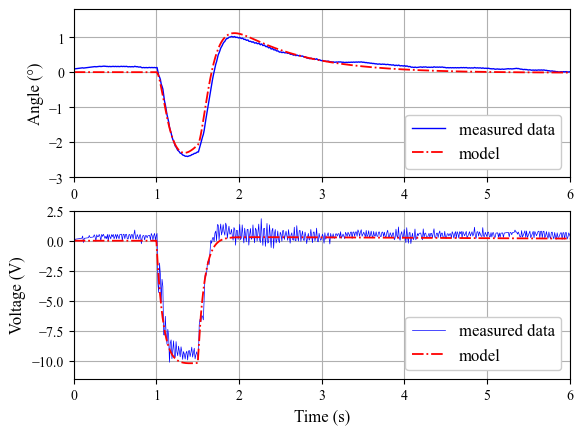

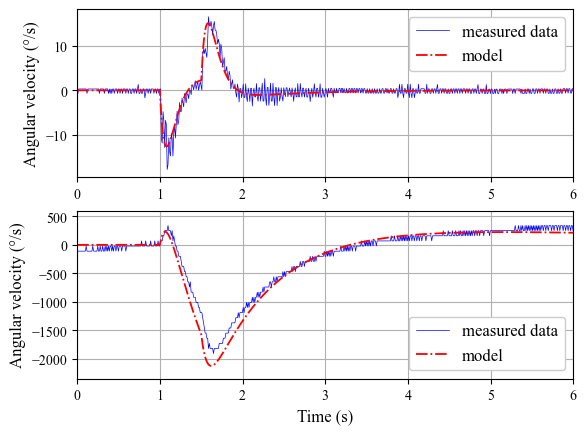

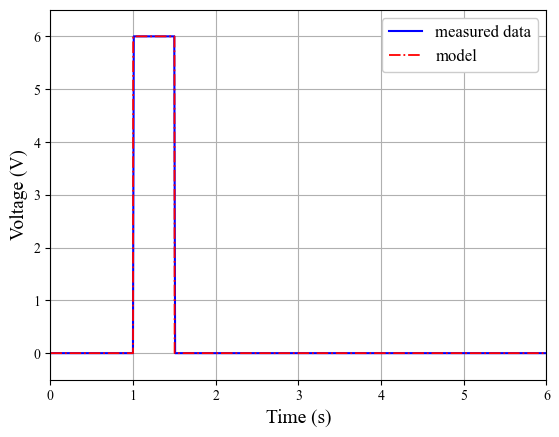

In [15]:
# =========================
# Experimental data - Pulse disturbance
# =========================

# Loads experimental data file
data = np.loadtxt('pulseData.txt')

# Data interval used in the analysis
start = 1
end = 4000

# Plot limits
x_init = 0
x_final = 6

# Extracts selected data segment
data_segment = data[start-1:end, :]


# Experimental signals
time = data_segment[:, 0] - 60
angle1 = data_segment[:, 1] * 57.296
angle2 = data_segment[:, 2] * 57.296
angle3 = data_segment[:, 3] * 57.296
input_signal = data_segment[:, 4]
disturbance = data_segment[:, 5]


# Simulation signals
time_sim = t[:len(theta_history)]

angle1_sim = np.rad2deg(theta_history)
angle2_sim = np.rad2deg(theta_dot_history)
angle3_sim = np.rad2deg(omega_history)

input_sim = u_history
disturbance_sim = disturbance_history


# =========================
# Figure 1
# =========================
plt.figure()


# Tilt angle comparison
plt.subplot(2, 1, 1)

plt.plot(time, angle1 + 0.06, 'b', linewidth=1)
plt.plot(time_sim, angle1_sim, '-.r', linewidth=1.3)

plt.ylabel('Angle (°)', fontsize=12)

plt.legend(['measured data', 'model'],
           loc='best',
           fontsize=12,
           framealpha=1.0)

plt.grid(True, alpha=1.0)

plt.xlim([x_init, x_final])
plt.ylim([-3, 1.8])


# Control signal comparison
plt.subplot(2, 1, 2)

plt.plot(time, input_signal, 'b', linewidth=0.5)
plt.plot(time_sim, input_sim, '-.r', linewidth=1.3)

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Voltage (V)', fontsize=12)

plt.legend(['measured data', 'model'],
           loc='best',
           fontsize=12,
           framealpha=1.0)

plt.grid(True, alpha=1.0)

plt.xlim([x_init, x_final])
plt.ylim([-11.5, 2.5])


# Saves figure
plt.savefig('pulse1.pdf',
            format='pdf',
            bbox_inches='tight',
            facecolor='white')


# =========================
# Figure 2
# =========================
plt.figure()


# Body angular velocity comparison
plt.subplot(2, 1, 1)

plt.plot(time, angle2, 'b', linewidth=0.5)
plt.plot(time_sim, angle2_sim, '-.r', linewidth=1.3)

plt.ylabel('Angular velocity (°/s)', fontsize=12)

plt.legend(['measured data', 'model'],
           loc='best',
           fontsize=12,
           framealpha=1.0)

plt.grid(True, alpha=1.0)

plt.xlim([x_init, x_final])


# Wheel angular velocity comparison
plt.subplot(2, 1, 2)

plt.plot(time, angle3 - 110, 'b', linewidth=0.5)
plt.plot(time_sim, angle3_sim, '-.r', linewidth=1.3)

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Angular velocity (°/s)', fontsize=12)

plt.legend(['measured data', 'model'],
           loc='best',
           fontsize=12,
           framealpha=1.0)

plt.grid(True, alpha=1.0)

plt.xlim([x_init, x_final])
plt.ylim([-2350, 600])


# Saves figure
plt.savefig('pulse2.pdf',
            format='pdf',
            bbox_inches='tight',
            facecolor='white')


# =========================
# Figure 3
# =========================
plt.figure()


# Disturbance comparison
plt.plot(time, disturbance, 'b', linewidth=1.5)
plt.plot(time_sim, disturbance_sim, '-.r', linewidth=1.3)

plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Voltage (V)', fontsize=14)

plt.legend(['measured data', 'model'],
           loc='best',
           fontsize=12,
           framealpha=1.0)

plt.grid(True, alpha=1.0)

plt.xlim([x_init, x_final])
plt.ylim([-0.5, 6.5])


# Saves figure
plt.savefig('pulse3.pdf',
            format='pdf',
            bbox_inches='tight',
            facecolor='white')


# Displays all figures
plt.show()

### Comparison between experimental and simulated responses of the system under step disturbance conditions.

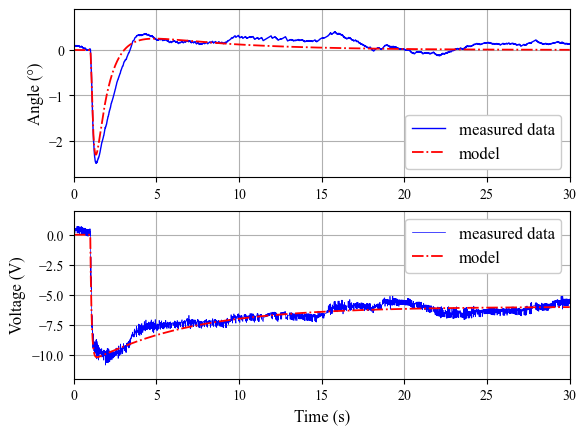

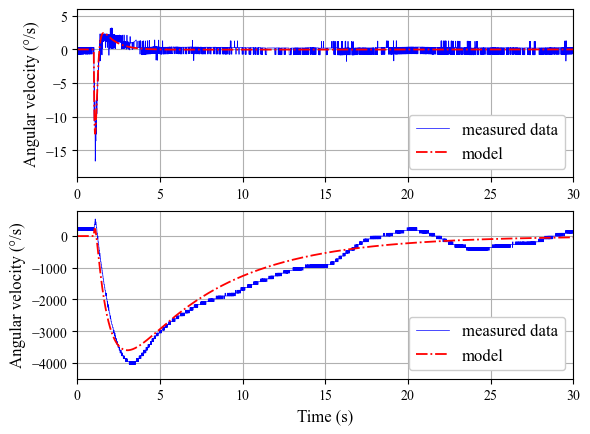

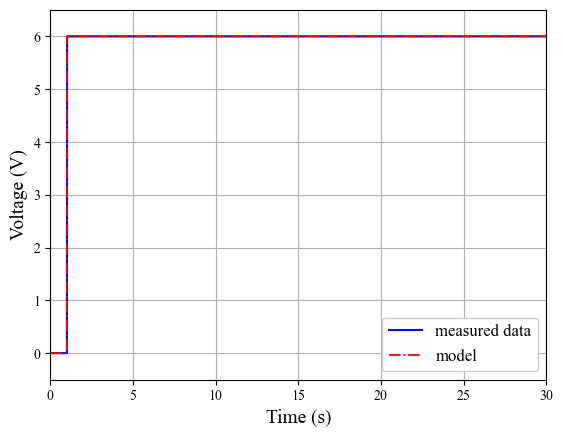

In [19]:
# =========================
# Experimental data - Step disturbance
# =========================

# Loads experimental data file
data = np.loadtxt('stepData.txt')

# Data interval used in the analysis
start = 1
end = 4000

# Plot limits
x_init = 0
x_final = 30

# Extracts selected data segment
data_segment = data[start-1:end, :]


# Experimental signals
time = data_segment[:, 0] - 60
angle1 = data_segment[:, 1] * 57.296
angle2 = data_segment[:, 2] * 57.296
angle3 = data_segment[:, 3] * 57.296
input_signal = data_segment[:, 4]
disturbance = data_segment[:, 5]


# Simulation signals
time_sim = t[:len(theta_history)]

angle1_sim = np.rad2deg(theta_history)
angle2_sim = np.rad2deg(theta_dot_history)
angle3_sim = np.rad2deg(omega_history)

input_sim = u_history
disturbance_sim = disturbance_history


# =========================
# Figure 1
# =========================
plt.figure()


# Tilt angle comparison
plt.subplot(2, 1, 1)

plt.plot(time, angle1 + 0.75, 'b', linewidth=1)
plt.plot(time_sim, angle1_sim, '-.r', linewidth=1.3)

plt.ylabel('Angle (°)', fontsize=12)

plt.legend(['measured data', 'model'],
           loc='best',
           fontsize=12,
           framealpha=1.0)

plt.grid(True, alpha=1.0)

plt.xlim([x_init, x_final])
plt.ylim([-2.8, 0.9])


# Control signal comparison
plt.subplot(2, 1, 2)

plt.plot(time, input_signal, 'b', linewidth=0.5)
plt.plot(time_sim, input_sim, '-.r', linewidth=1.3)

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Voltage (V)', fontsize=12)

plt.legend(['measured data', 'model'],
           loc='best',
           fontsize=12,
           framealpha=1.0)

plt.grid(True, alpha=1.0)

plt.xlim([x_init, x_final])
plt.ylim([-12, 2])


# Saves figure
plt.savefig('step1.pdf',
            format='pdf',
            bbox_inches='tight',
            facecolor='white')


# =========================
# Figure 2
# =========================
plt.figure()


# Body angular velocity comparison
plt.subplot(2, 1, 1)

plt.plot(time, angle2, 'b', linewidth=0.5)
plt.plot(time_sim, angle2_sim, '-.r', linewidth=1.3)

plt.ylabel('Angular velocity (°/s)', fontsize=12)

plt.legend(['measured data', 'model'],
           loc='best',
           fontsize=12,
           framealpha=1.0)

plt.grid(True, alpha=1.0)

plt.xlim([x_init, x_final])
plt.ylim([-19, 6])


# Wheel angular velocity comparison
plt.subplot(2, 1, 2)

plt.plot(time, angle3, 'b', linewidth=0.5)
plt.plot(time_sim, angle3_sim, '-.r', linewidth=1.3)

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Angular velocity (°/s)', fontsize=12)

plt.legend(['measured data', 'model'],
           loc='best',
           fontsize=12,
           framealpha=1.0)

plt.grid(True, alpha=1.0)

plt.xlim([x_init, x_final])
plt.ylim([-4500, 800])


# Saves figure
plt.savefig('step2.pdf',
            format='pdf',
            bbox_inches='tight',
            facecolor='white')


# =========================
# Figure 3
# =========================
plt.figure()


# Disturbance comparison
plt.plot(time, disturbance, 'b', linewidth=1.5)
plt.plot(time_sim, disturbance_sim, '-.r', linewidth=1.3)

plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Voltage (V)', fontsize=14)

plt.legend(['measured data', 'model'],
           loc='best',
           fontsize=12,
           framealpha=1.0)

plt.grid(True, alpha=1.0)

plt.xlim([x_init, x_final])
plt.ylim([-0.5, 6.5])


# Saves figure
plt.savefig('step3.pdf',
            format='pdf',
            bbox_inches='tight',
            facecolor='white')


# Displays all figures
plt.show()